# 연속 위치·allele Point-process EB

exact allele → codon → 20aa Gaussian local density → gene×event-type EB 순으로 backoff하여 26×(sum/max/top2) 점수를 만듭니다. 위치·통계·정규화는 outer fold-train과 inner cross-fit에 한정합니다.

seed 42 screen만 수행합니다. 사전 승격 조건(+0.010, 4/5 fold 양수, 안전성 통과)을 만족한 하나의 구성만 3-seed로 확장합니다.


In [1]:
from pathlib import Path
import subprocess, sys
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents)
            if (path / "experiments/gs/notebooks/exp_model_003/common/run_p1_eb_axis.py").exists())
COMMON = ROOT / "experiments/gs/notebooks/exp_model_003/common"
RESULT = ROOT / "experiments/gs/notebooks/exp_model_003/result"
RUNNER = COMMON / "run_p1_eb_axis.py"
assert RUNNER.exists(), RUNNER


/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 42
RUN_EXPERIMENT = True  # 전체 OOF 실행 전에는 False로 둘 수 있습니다.
RUN_ID = "exp-point-process-eb-01"

if RUN_EXPERIMENT:
    command = [sys.executable, str(RUNNER), "--axis", "point", "--seed", str(SEED), "--run-id", RUN_ID]
    process = subprocess.Popen(command, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    tail = []
    for line in tqdm(process.stdout, desc="OOF runner", unit="line"):
        print(line, end="")
        tail = (tail + [line])[-120:]
    return_code = process.wait()
    if return_code:
        raise RuntimeError(f"runner failed (exit={return_code}). Last runner output:\n" + "".join(tail))
else:
    print("RUN_EXPERIMENT=False: 기존 결과만 조회합니다.")


OOF runner: 3line [00:06,  1.64s/line]


row-local mutation cache:   1%|          | 37/4384 [00:00<00:11, 369.80it/s]


OOF runner: 5line [00:06,  1.28line/s]

row-local mutation cache:   3%|▎         | 116/4384 [00:00<00:12, 329.60it/s]


OOF runner: 7line [00:06,  2.39line/s]

...

OOF runner: 219line [06:47,  9.83line/s]

row-local mutation cache: 100%|██████████| 4384/4384 [00:10<00:00, 401.91it/s]


OOF runner: 222line [07:25,  7.17s/line]

         variant  oof_macro_f1  feature_count  convergence_warning_count  leakage_check  nan_as_mutation_count  delta_vs_eb
        P1+EB LR      0.534416         8201.2                          0           True                      0     0.000000
point_process_eb      0.518255         8279.2                          0           True                      0    -0.016161
runtime_seconds=444.31


OOF runner: 225line [07:25,  1.98s/line]


,variant,oof_macro_f1,feature_count,convergence_warning_count,leakage_check,nan_as_mutation_count,delta_vs_eb
0,P1+EB LR,0.534416,8201.2,0,True,0,0.000000
1,point_process_eb,0.518255,8279.2,0,True,0,-0.016161


,fold,macro_f1,feature_count,variant
0,1,0.513318,8160,P1+EB LR
1,2,0.544631,8203,P1+EB LR
2,3,0.530545,8169,P1+EB LR
3,4,0.552202,8249,P1+EB LR
4,5,0.532630,8225,P1+EB LR
5,1,0.511778,8238,point_process_eb
6,2,0.522510,8281,point_process_eb
7,3,0.524796,8247,point_process_eb
8,4,0.519882,8327,point_process_eb
9,5,0.510345,8303,point_process_eb


/var/folders/9x/vt0mtt2d7lgdvmbfksllhnqc0000gn/T/ipykernel_23373/1092950167.py:7: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/9x/vt0mtt2d7lgdvmbfksllhnqc0000gn/T/ipykernel_23373/1092950167.py:7: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/9x/vt0mtt2d7lgdvmbfksllhnqc0000gn/T/ipykernel_23373/1092950167.py:7: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/9x/vt0mtt2d7lgdvmbfksllhnqc0000gn/T/ipykernel_23373/1092950167.py:7: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu 

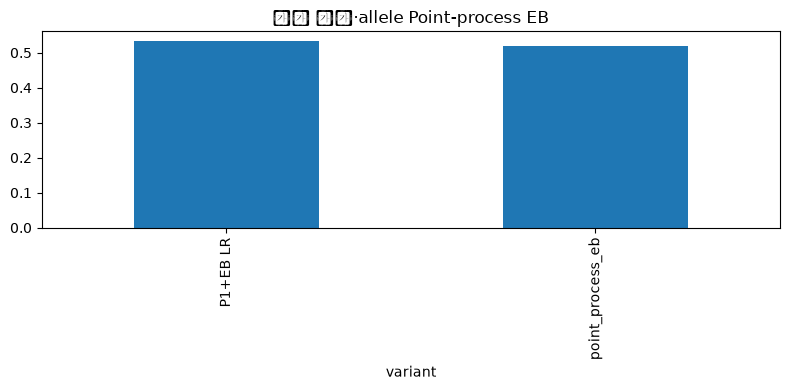

In [3]:
summary = pd.read_csv(RESULT / f"exp-point-process-eb-01_seed{SEED}_summary.csv")
folds = pd.read_csv(RESULT / f"exp-point-process-eb-01_seed{SEED}_fold_metrics.csv")
display(summary); display(folds)
assert summary.leakage_check.all()
assert summary.nan_as_mutation_count.eq(0).all()
summary.set_index("variant")["oof_macro_f1"].plot.bar(figsize=(8, 4), title="연속 위치·allele Point-process EB")
plt.tight_layout(); plt.show()
